# **Prediksi Churn Pelanggan**

# Week 2 - Direct Modeling

**Dataset:** Sales and Marketing Customer Dataset  
**Unit Kompetensi:** Membangun model dasar dan menghasilkan prediksi awal.

Pada tahap ini model dilatih **langsung tanpa preprocessing rapi dan tanpa hyperparameter tuning** untuk menghasilkan baseline. Hanya dilakukan penanganan minimal (imputasi & encoding) agar data dapat diterima oleh model.

## Load Data & Library

In [1]:
import warnings
warnings.filterwarnings('ignore')  # sembunyikan warning non-kritis (Pandas4/Convergence/Future)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load dataset
df = pd.read_csv('../dataset/Sales - Marketing customer dataset.csv')
print(f'Dataset berhasil dimuat dengan {df.shape[0]} baris dan {df.shape[1]} kolom.')

Dataset berhasil dimuat dengan 15000 baris dan 30 kolom.


## 1. Menetapkan Variabel Target (y) dan Fitur Prediktor (X)

Target: `churn`. Fitur: 29 kolom lainnya. Karena tahap ini *direct* (tanpa preprocessing rapi), missing value hanya ditangani seadanya — **kategorikal pakai modus**, **numerik pakai median** — lalu kolom kategorikal di-encode dengan Label Encoding supaya model bisa langsung dilatih.

In [3]:
# ============================================================
# TUGAS 1: Menetapkan fitur prediktor (X) dan target (y)
# ------------------------------------------------------------
# Catatan: ini tahap DIRECT, jadi penanganan data dibuat MINIMAL
# (hanya supaya model bisa jalan). Tidak ada scaling/outlier handling.
# ============================================================
df_model = df.copy()

# Pisahkan kolom berdasarkan tipe data
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df_model.select_dtypes(include=np.number).columns if c != 'churn']

# Imputasi missing value seadanya:
#  - kategorikal -> modus (nilai paling sering muncul)
#  - numerik     -> median (lebih tahan outlier dibanding mean)
for col in cat_cols:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])
for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Label Encoding: ubah teks kategorikal -> angka agar bisa diterima model.
# Dipilih krn cepat & tidak menambah dimensi (One-Hot baru dipakai di Week 3).
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# X = semua kolom selain churn; y = kolom target churn
X = df_model.drop(columns=['churn'])
y = df_model['churn']

print(f'Fitur prediktor (X) : {X.shape[1]} kolom')
print(f'Jumlah sampel       : {X.shape[0]}')
print(f'Sisa missing value  : {int(X.isna().sum().sum())}')
print('\nDistribusi target y :')
print(y.value_counts())

Fitur prediktor (X) : 29 kolom
Jumlah sampel       : 15000
Sisa missing value  : 0

Distribusi target y :
churn
0    12702
1     2298
Name: count, dtype: int64


## 2. Train-Test Split

Data dibagi 80% latih / 20% uji dengan `stratify=y` agar proporsi churn konsisten di kedua set.

In [4]:
# ============================================================
# TUGAS 2: Train-Test Split (80% latih, 20% uji)
# ------------------------------------------------------------
# stratify=y  -> proporsi kelas churn (15%) dijaga sama di train & test,
#               penting karena data imbalance.
# random_state=42 -> hasil split konsisten (bisa direproduksi).
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Data latih : {X_train.shape}')
print(f'Data uji   : {X_test.shape}')
print(f'\nDistribusi y_train:\n{y_train.value_counts()}')
print(f'\nDistribusi y_test :\n{y_test.value_counts()}')

Data latih : (12000, 29)
Data uji   : (3000, 29)

Distribusi y_train:
churn
0    10162
1     1838
Name: count, dtype: int64

Distribusi y_test :
churn
0    2540
1     460
Name: count, dtype: int64


## 3. Pemilihan Tiga Model

- **Logistic Regression** — model konvensional.
- **Random Forest** — ensemble bagging.
- **VotingClassifier (LR + SVM + KNN)** — gabungan beberapa model konvensional.

In [5]:
# ============================================================
# TUGAS 3: Memilih 3 model dari 3 kategori berbeda
# ============================================================
# Model 1 - KONVENSIONAL
# max_iter=1000 agar Logistic Regression cukup iterasi untuk konvergen.
model_lr = LogisticRegression(random_state=42, max_iter=1000)

# Model 2 - ENSEMBLE BAGGING (gabungan banyak decision tree)
model_rf = RandomForestClassifier(random_state=42)

# Model 3 - GABUNGAN beberapa model konvensional (VotingClassifier)
# voting='soft' -> keputusan diambil dari rata-rata PROBABILITAS tiap model,
# bukan sekadar suara terbanyak (lebih halus).
model_vc = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
        ('svm', SVC(probability=True, random_state=42)),
        ('knn', KNeighborsClassifier())
    ],
    voting='soft'
)

print('Tiga model siap dilatih.')

Tiga model siap dilatih.


## 4. Training Model

Latih ketiga model langsung tanpa scaling/preprocessing tambahan dan tanpa tuning.

In [6]:
# ============================================================
# TUGAS 4: Melatih ketiga model LANGSUNG (tanpa tuning)
# .fit() = proses model belajar pola dari data latih.
# ============================================================
print('Training Logistic Regression...', end=' ')
model_lr.fit(X_train, y_train)
print('selesai.')

print('Training Random Forest...', end=' ')
model_rf.fit(X_train, y_train)
print('selesai.')

print('Training VotingClassifier...', end=' ')
model_vc.fit(X_train, y_train)
print('selesai.')

print('\nSemua model berhasil dilatih.')

Training Logistic Regression... 

selesai.
Training Random Forest... 

selesai.
Training VotingClassifier... 

selesai.

Semua model berhasil dilatih.


## 5. Evaluasi Model

Evaluasi pakai *Accuracy*, *Precision*, *Recall*, *F1-Score* dan *Confusion Matrix* untuk tiap model.

In [7]:
# ============================================================
# TUGAS 5: Evaluasi performa (Accuracy, Precision, Recall, F1)
# ------------------------------------------------------------
# .predict() -> model menebak churn/tidak pada DATA UJI (yang belum dilihat).
# zero_division=0 -> hindari error jika pembagi 0 saat hitung metrik.
# ============================================================
models = {
    'Logistic Regression'          : model_lr,
    'Random Forest'                : model_rf,
    'VotingClassifier (LR+SVM+KNN)': model_vc,
}

rows = []
for name, mdl in models.items():
    yp = mdl.predict(X_test)
    rows.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, zero_division=0),
        'Recall'   : recall_score(y_test, yp, zero_division=0),
        'F1-Score' : f1_score(y_test, yp, zero_division=0),
    })

metrics_df = pd.DataFrame(rows).set_index('Model').round(4)
print('=== Ringkasan Metrik Evaluasi ===')
print(metrics_df.to_string())

=== Ringkasan Metrik Evaluasi ===
                               Accuracy  Precision  Recall  F1-Score
Model                                                               
Logistic Regression              0.8473     0.5072  0.1522    0.2341
Random Forest                    0.8553     0.5419  0.3652    0.4364
VotingClassifier (LR+SVM+KNN)    0.8470     0.6000  0.0065    0.0129


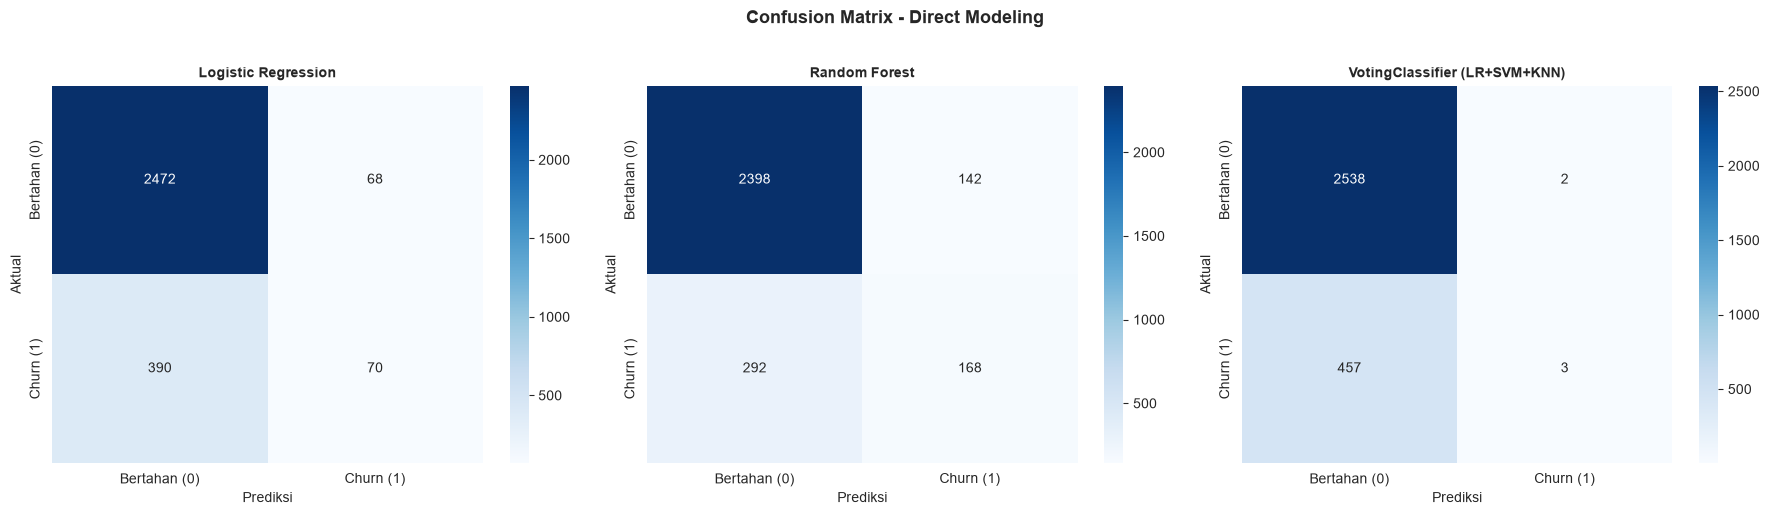

In [8]:
# ============================================================
# TUGAS 5 (lanjut): Confusion Matrix tiap model
# ------------------------------------------------------------
# Confusion matrix menunjukkan: prediksi benar/salah dipecah per kelas.
#   - diagonal  = prediksi BENAR
#   - off-diagonal = prediksi SALAH (mis. churn diprediksi bertahan)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, mdl) in zip(axes, models.items()):
    yp = mdl.predict(X_test)
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Bertahan (0)', 'Churn (1)'],
                yticklabels=['Bertahan (0)', 'Churn (1)'])
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix - Direct Modeling', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight Direct Modeling:**
- Semua 29 fitur dipakai (numerik + kategorikal yang sudah di-encode).
- Random Forest unggul (F1 ~0.44) karena tahan terhadap fitur yang belum di-scale.
- VotingClassifier punya precision tinggi tapi recall sangat rendah (~0.01) karena SVM & KNN sensitif terhadap skala, sedangkan scaling belum diterapkan di tahap ini.
- Recall kelas Churn (1) cenderung rendah akibat class imbalance (~85% vs ~15%).
- Hasil ini menjadi **baseline** sebelum preprocessing diterapkan di Week 3.